# 06 PCA Figure

Notebook to make PCA figures.

In [1]:
# Packages
library(sva)
library(ggplot2)
library(limma)
library(ComplexHeatmap)
library(circlize)
library(viridis)


# Set working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/cutnrun")

Loading required package: mgcv

Loading required package: nlme

This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Loading required package: genefilter

Loading required package: BiocParallel

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



Attaching package: ‘ComplexHeatmap’


The following object is ma

Reload data

In [ ]:
# Load R image
load("06_replicates/replicatesR_PCA.RData")

# Theme
# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(      base_size = 14,
                        base_family = "sans"
                        ) +
    theme(  axis.text   = element_text(size = 12),
            axis.title = element_text(size = 12),
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank() # Remove gridlines
            )  


# Change PCA function
plotPCA <- function(pca, meta) {

    pcs <- as.data.frame(pca$x)

    if( !all(rownames(pcs) == meta$Sample) ) {
        stop("rownames(pca$x) and meta$Sample do not match")
    }

    pcs <- as.data.frame(pca$x)
    pcs <- cbind(meta, pcs)

    colors <- c(
        shCd19  = "#808180",
        shRunx3 = "#DC0000",
        'Tcf7+' = "#59A14F",
        a       = "#1D2B53",
        b       = "#7E2553",
        c       = "#F77777"
    )

    # Change values of Phenotype to specific names
    pcs$Phenotype[pcs$Phenotype == "memory"]     <- "Tcf7+"
    pcs$Phenotype[pcs$Phenotype == "early"]      <- "a"
    pcs$Phenotype[pcs$Phenotype == "late"]       <- "b"
    pcs$Phenotype[pcs$Phenotype == "terminal"]   <- "c"

    pcs$Factor    <- factor(pcs$Factor)
    pcs$Phenotype <- factor(pcs$Phenotype, levels = c("shCd19", "shRunx3", "Tcf7+", "a", "b", "c"))
    pcs$Replicate <- factor(pcs$Replicate)
    pcs$FactorRep <- paste(pcs$Factor, pcs$Replicate)   # e.g. "Runx1 1", "Runx3 2"

    f <- levels(pcs$Factor)   # the two targets, e.g. c("Runx1", "Runx3")

    p <- ggplot(pcs, aes(PC1, PC2, colour = Phenotype)) +
        geom_point(size = 4, stroke = 1) +
        labs(x = "PC1", y = "PC2") +
        theme +
        scale_colour_manual(values = colors) +
        coord_fixed(ratio = 1)
    return(p)
    
}

pdf 
  2

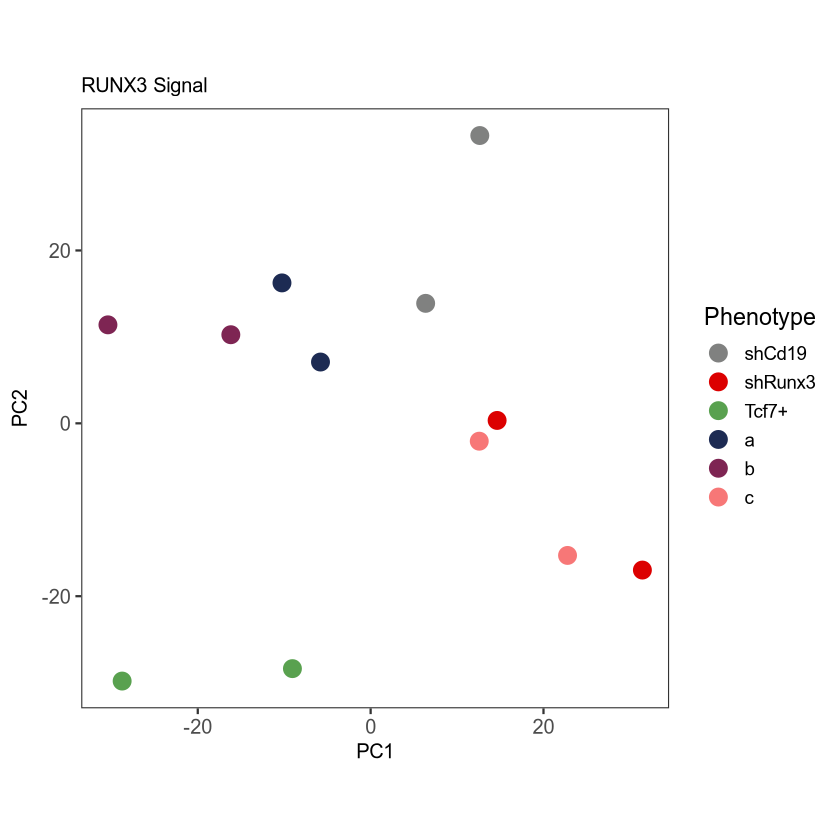

In [27]:
p <- plotPCA(pca.z.batch.r3, meta_r3) + ggtitle("RUNX3 Signal")
print(p)
pdf(file = "06_replicates/replicatesPCA_R3.pdf", width = 4, height = 3)
print(p)
dev.off()

pdf 
  2

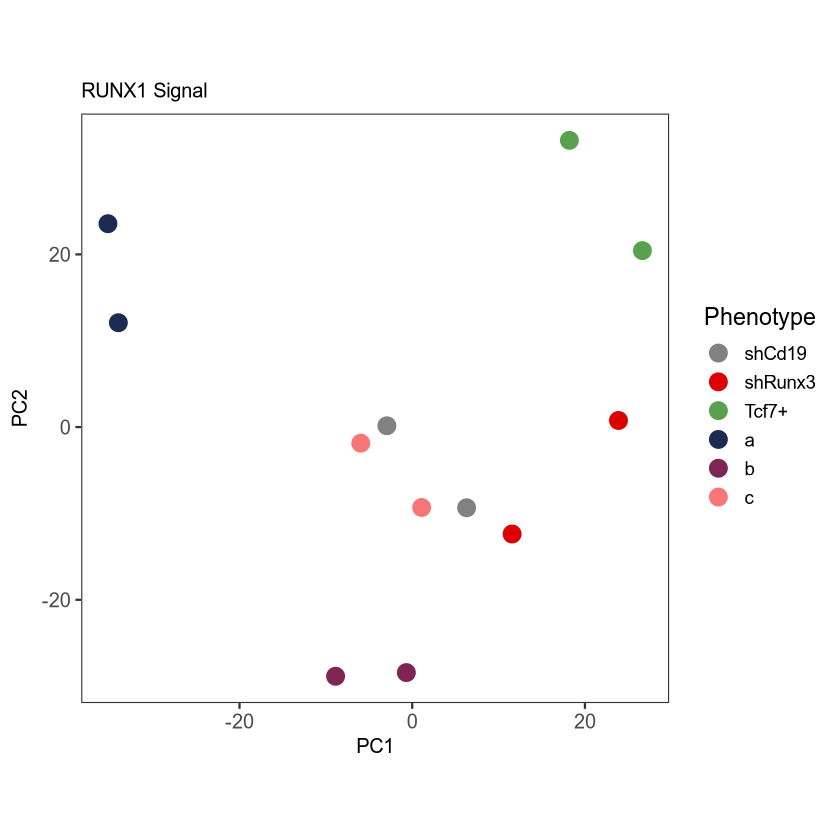

In [28]:
p <- plotPCA(pca.z.batch.r1, meta_r1) + ggtitle("RUNX1 Signal")
print(p)
pdf(file = "06_replicates/replicatesPCA_R1.pdf", width = 4, height = 3)
print(p)
dev.off()